# Single clustering for cross-modality alignment

This notebook prepares one spatial transcriptomics sample for cross-modality
alignment. It accepts either AnnData/H5AD or a paired metadata/expression CSV
input, runs single-sample BANKSY, optionally applies boundary-aware refinement,
and writes the canonical labels `cluster_raw`, `cluster_refined`, and `cluster`.

The example is the adult mouse brain MERFISH S2R1 sample (83,546 cells and 649
measured genes). The resulting `AnnData` is the direct input to the ST-to-Allen
CCF notebook; there is no intermediate research-script CSV contract.

**Fixed-seed reproducibility.** This workflow uses seed `1234`. Launch Python with `PYTHONHASHSEED` set before kernel startup, then keep the documented input order, package versions and configuration fixed. Discrete labels/pairs are expected to match exactly; CUDA coordinates are compared with the documented numerical tolerance.

## Installation and data

From the repository root:

```bash
cd /path/to/spAlignDE
python -m pip install -e ".[clustering,atlas,tutorial]"
```

Download the MERFISH Mouse Brain Receptor Map from
[Vizgen](https://info.vizgen.com/mouse-brain-map). Put either input form in
`data/cross_modality/mouse_brain/merfishS2/`, or set
`SPALIGNDE_ST_DATA_DIR` to another directory.

| Input form | Required files | Required fields |
|---|---|---|
| AnnData | `merfishS2_single.h5ad` | cell-by-gene `X`; finite `(n_obs, 2)` coordinates in `obsm["spatial"]`, or numeric `obs["x"]` and `obs["y"]` |
| CSV | `cell_metadata_S2R1.csv` and `cell_by_gene_S2R1.csv` | metadata: unique `cell_id`, numeric `x`, `y`; expression: the same `cell_id` values plus numeric, non-negative gene columns |

Set `SPALIGNDE_SINGLE_INPUT=csv` to exercise the CSV route. Both routes are
normalized by `spAlignDE.load_single_sample_data` to the same AnnData contract.

In [1]:
%matplotlib inline

from pathlib import Path
import os
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import spAlignDE

WORKFLOW_SEED = 1234
seed_controls = spAlignDE.set_random_seed(
    WORKFLOW_SEED,
    deterministic_torch=True,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from the spAlignDE repository.")


PROJECT_ROOT = find_project_root(Path.cwd())
public_data_dir = PROJECT_ROOT / "data" / "cross_modality" / "mouse_brain" / "merfishS2"
DATA_DIR = Path(os.environ.get("SPALIGNDE_ST_DATA_DIR", public_data_dir)).expanduser()

OUTPUT_DIR = PROJECT_ROOT / "tutorials" / "cross_modality" / "atlas" / "output"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

INPUT_MODE = os.environ.get("SPALIGNDE_SINGLE_INPUT", "h5ad").strip().lower()

if INPUT_MODE in {"h5ad", "anndata"}:
    input_adata = spAlignDE.load_single_sample_data(DATA_DIR / "merfishS2_single.h5ad")
elif INPUT_MODE == "csv":
    input_adata = spAlignDE.load_single_sample_data(
        DATA_DIR / "cell_metadata_S2R1.csv",
        expression_csv=DATA_DIR / "cell_by_gene_S2R1.csv",
    )
else:
    raise ValueError("SPALIGNDE_SINGLE_INPUT must be 'h5ad' or 'csv'.")

print(f"Input mode: {INPUT_MODE}")
print(f"Input AnnData: {input_adata.n_obs:,} cells × {input_adata.n_vars:,} genes")

Input mode: h5ad
Input AnnData: 83,546 cells × 649 genes


## Run single-sample BANKSY

`banksy_lambda=0.8` and `resolution=1.2` reproduce the setting used for the
paper's S2R1 atlas experiment. BANKSY incorporates each cell's expression and
spatial-neighborhood features. Boundary-aware refinement uses fewer neighbors
near the tissue edge so thin anatomical structures are not erased by a global
majority vote.

This is a fresh package run. The notebook writes its clustered AnnData once;
the following alignment notebook reads that file as the explicit handoff
between the two workflow steps.

In [2]:
config = spAlignDE.SingleClusteringConfig(
    num_neighbors=30,
    banksy_lambda=0.8,
    resolution=1.2,
    max_m=1,
    decay="scaled_gaussian",
    random_state=WORKFLOW_SEED,
    refine_boundaries=True,
)

clustered = spAlignDE.cluster_single(
    input_adata,
    config=config,
    banksy_output_dir=OUTPUT_DIR / "banksy_diagnostics",
)

spAlignDE.validate_single_sample_anndata(
    clustered,
    cluster_key="cluster",
    require_cluster=True,
)
print("Mode: fresh package run")
print("Raw clusters:", clustered.obs["cluster_raw"].nunique())
print("Refined clusters:", clustered.obs["cluster_refined"].nunique())

Mode: fresh package run
Raw clusters: 25
Refined clusters: 25


### How to adapt the clustering parameters

Tune clustering before changing alignment parameters. Keep the random seed and
all other settings fixed while comparing a small grid of candidate values.

- `num_neighbors`: increasing it summarizes a broader spatial neighborhood and
  usually smooths structures; reduce it if thin domains disappear.
- `banksy_lambda`: increasing it gives spatial-neighborhood information more
  influence relative to each observation's own expression.
- `resolution`: increasing it usually produces more Leiden clusters. Reject
  settings that create many tiny sample-specific fragments or merge clearly
  distinct spatial domains.
- `snn_neighbors` and `harmony_theta` (joint clustering only): the former
  broadens graph connectivity and the latter strengthens sample correction.
  Do not erase biological differences merely to maximize shared labels.
- `refine_boundaries`: compare `cluster_raw` and `cluster_refined` spatially.
  Refinement should remove isolated boundary noise without erasing narrow
  structures.

Select a configuration using spatial coherence, boundary preservation, cluster
size and coverage in every required sample. Cluster integer values are
arbitrary and may be renumbered across runs; compare memberships and maps, not
label numbers. The website **Parameter Tuning Guide** gives the complete
clustering-to-alignment tuning order.

## Inspect raw and refined spatial structures

The final QC plot deliberately reproduces the original documentation palette:
labels are ordered lexicographically and assigned the discrete colors in
Matplotlib `tab20`, cycling only if more than 20 labels are present. The same
label-to-color dictionary is reused in both panels, so color changes cannot be
mistaken for boundary-refinement changes. For paper-scale point clouds, the
scatter layer is rasterized while axes and text remain vector-editable.


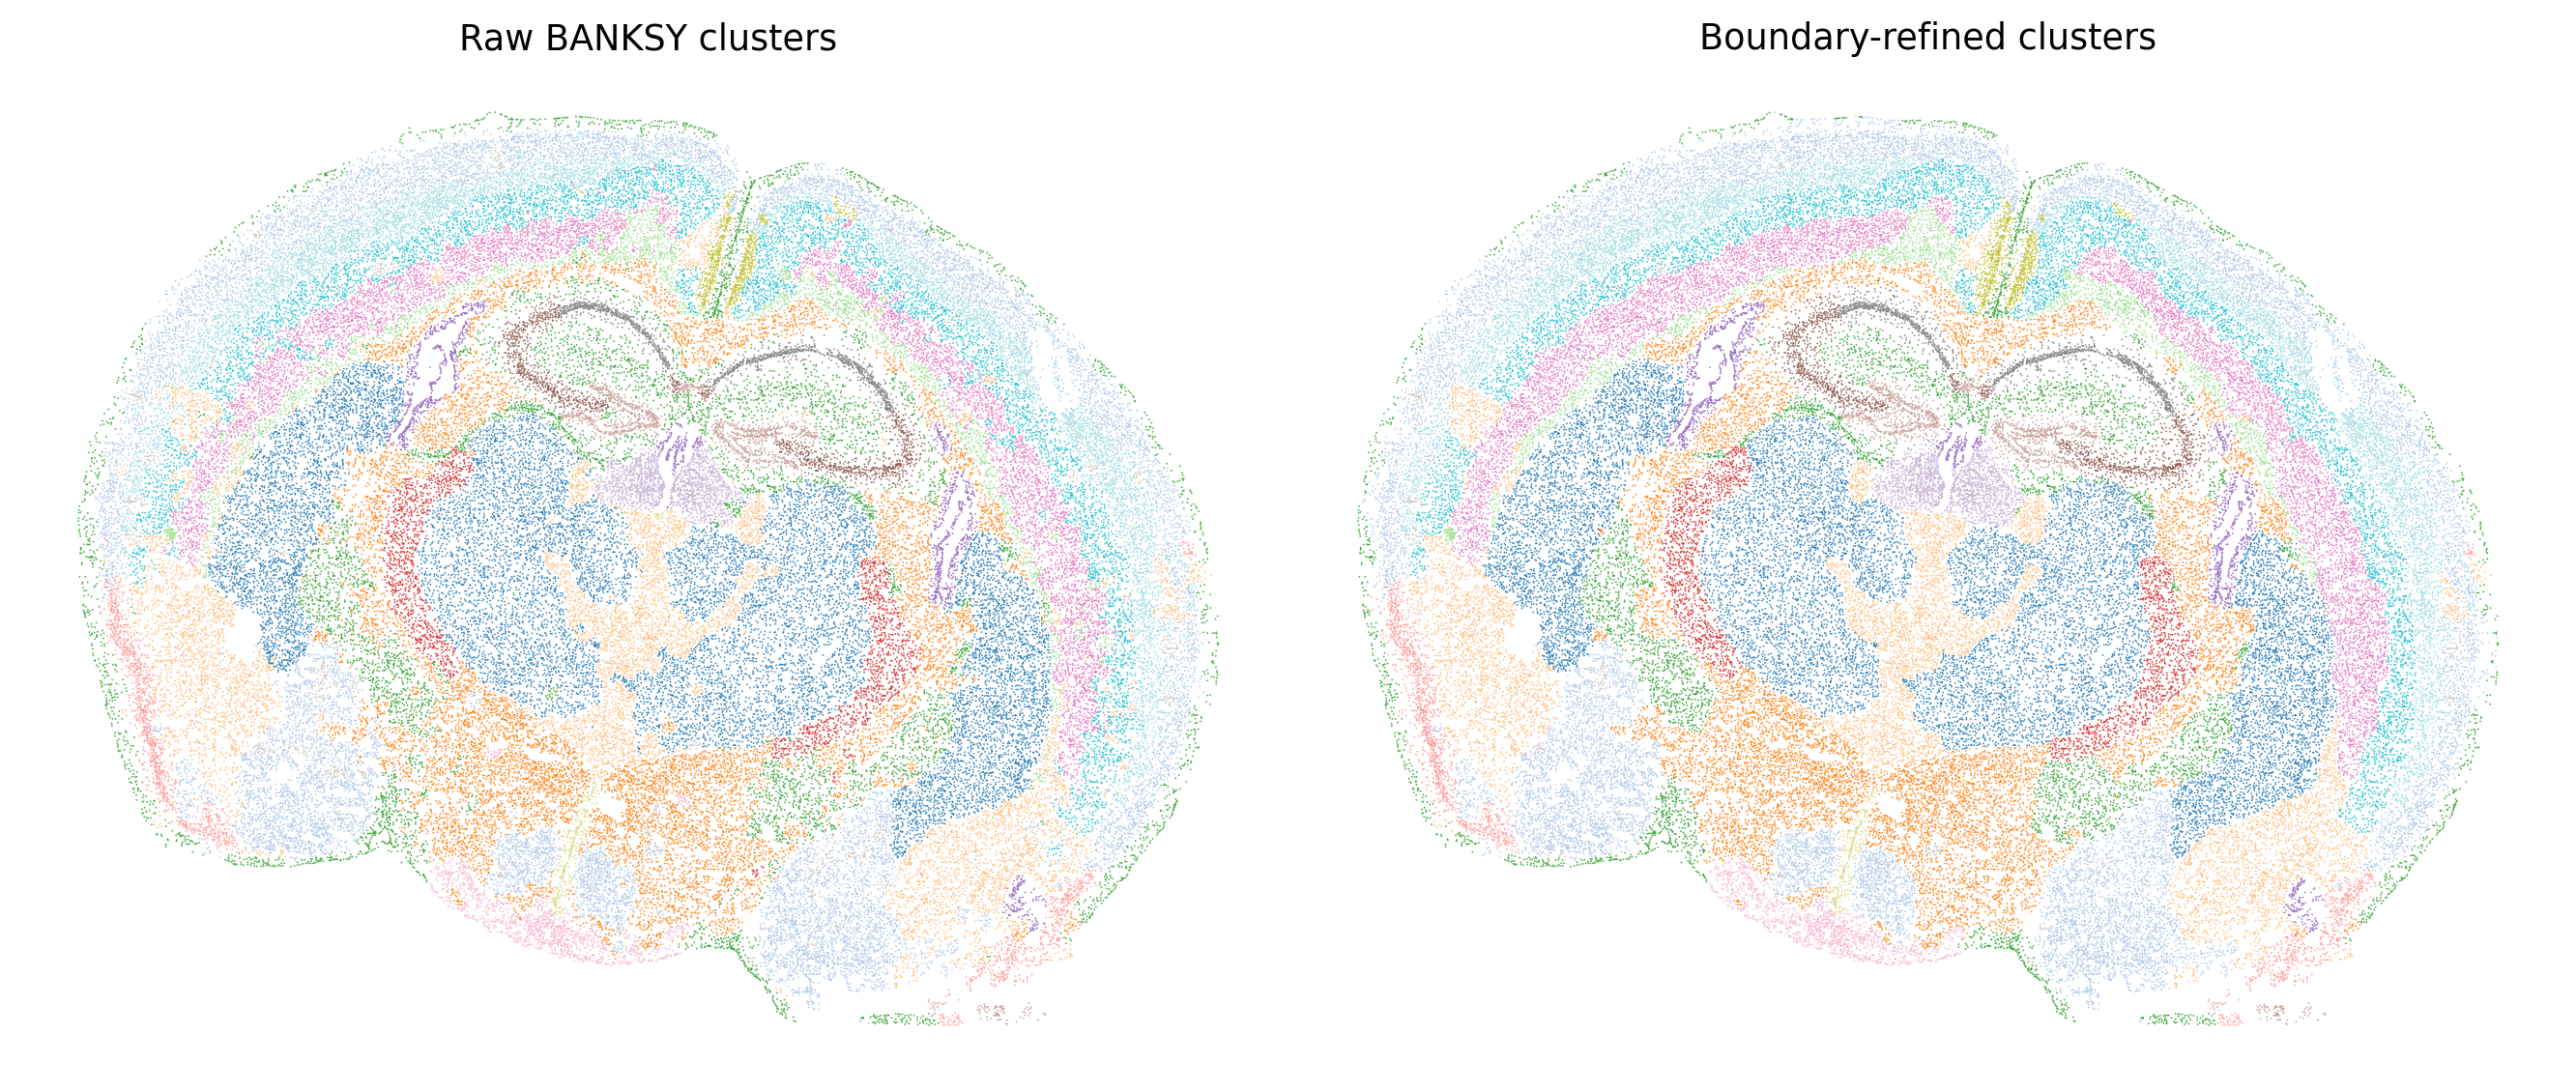

In [3]:
raw_labels = clustered.obs["cluster_raw"].astype(str)
refined_labels = clustered.obs["cluster_refined"].astype(str)
legacy_label_order = pd.Index(raw_labels.unique()).union(
    pd.Index(refined_labels.unique())
).sort_values()
legacy_palette = list(plt.get_cmap("tab20").colors)
legacy_color_map = {
    label: legacy_palette[index % len(legacy_palette)]
    for index, label in enumerate(legacy_label_order)
}

xy = clustered.obsm["spatial"]
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), constrained_layout=True)
for axis, key, title in zip(
    axes,
    ("cluster_raw", "cluster_refined"),
    ("Raw BANKSY clusters", "Boundary-refined clusters"),
):
    labels = clustered.obs[key].astype(str)
    axis.scatter(
        xy[:, 0],
        xy[:, 1],
        c=[legacy_color_map[label] for label in labels],
        s=0.35,
        alpha=0.85,
        linewidths=0,
        rasterized=True,
    )
    axis.set_title(title)
    axis.set_aspect("equal")
    axis.axis("off")
    axis.invert_yaxis()

fig.savefig(FIGURE_DIR / "single_clustering_raw_vs_refined.png", dpi=220, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "single_clustering_raw_vs_refined.svg", bbox_inches="tight")
plt.show()


## Save the canonical clustered AnnData

The original expression matrix and `obsm["spatial"]` remain unchanged. The
three package-owned columns are:

- `cluster_raw`: selected BANKSY labels;
- `cluster_refined`: boundary-refined labels; and
- `cluster`: labels selected for downstream alignment.

Package provenance is stored only under `adata.uns["spAlignDE"]`.

In [4]:
clustered_path = OUTPUT_DIR / "merfish_S2R1_single_clustered.h5ad"
clustered.write_h5ad(clustered_path)

summary = pd.DataFrame(
    {
        "value": [
            f"{clustered.n_obs:,}",
            f"{clustered.n_vars:,}",
            clustered.obs["cluster_raw"].nunique(),
            clustered.obs["cluster_refined"].nunique(),
            "cluster_raw, cluster_refined, cluster",
        ]
    },
    index=["cells", "genes", "raw clusters", "refined clusters", "output labels"],
)
display(summary)
print("Saved: tutorials/cross_modality/atlas/output/merfish_S2R1_single_clustered.h5ad")

Saved fixed-seed handoff: 83,546 observations × 649 genes.


## Next step

Open **ST-to-Allen-CCF alignment — MERFISH adult mouse brain**. It reads this
clustered AnnData, builds expression-based coarse-to-fine structure levels,
aligns S2R1 to Allen CCF slice 675, and transfers atlas labels to every cell.